# ICML Paper Figures

Paper-quality figures for ICML submission. All figures are formatted for two-column (figure*) layout.

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import LogLocator
import re
import os
from pathlib import Path
import wandb_buddy as wb

## ICML Paper Style Configuration

ICML two-column format:
- Text width: ~6.75 inches (full page figure*)
- Column width: ~3.25 inches (single column / subfigure)
- Font: Serif (Times) to match ICML LaTeX template

In [3]:
# ICML Paper Style - exact widths for single/double column
ICML_WIDTH_SINGLE = 3.25  # inches for single column
ICML_WIDTH_DOUBLE = 6.75  # inches for double column (figure*)

def setup_icml_style():
    """Configure matplotlib for ICML paper figures."""
    plt.rcParams.update({
        "text.usetex": True,           # Use LaTeX to render text
        "font.family": "serif",        # Use serif fonts to match paper
        "font.serif": ["Times"],       # Match the ICML Times New Roman
        "font.size": 6,               # Match body text size
        "axes.labelsize": 6,          # x/y label size
        "axes.titlesize": 6,          # Subplot title size
        "legend.fontsize": 7,          # Legend can be smaller
        "xtick.labelsize": 7,          # Ticks can be smaller
        "ytick.labelsize": 7,
        "figure.figsize": (ICML_WIDTH_SINGLE, 2.0),  # Width fixed, height adjustable
        "figure.autolayout": True,     # Similar to tight_layout
    })

setup_icml_style()
print("ICML paper style configured.")

ICML paper style configured.


## Load Data

In [4]:
# =============================================================================
# 1. Load wandb experiment data for transferability plot
# =============================================================================
TAG = "e23TG_neurogf_terrain_graph_2"
ENTITY = "alelab"
PROJECT = "terrains"
ERROR_COL = 'test_mae'
ERROR_LABEL = 'Test MAE'

print(f"Fetching runs with tag: {TAG}")
df = wb.load_runs(ENTITY, PROJECT, tags=[TAG])
print(f"Found {len(df)} runs")

Fetching runs with tag: e23TG_neurogf_terrain_graph_2


wandb: Currently logged in as: jotaporras (alelab) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Found 102 runs


In [5]:
# Extract resolution from dataset_name
def extract_resolution(row):
    dataset_name = str(row['dataset_name'])
    res_match = re.search(r'res(\d+)', dataset_name)
    return int(res_match.group(1))

df['resolution'] = df.apply(extract_resolution, axis=1)
df['density'] = 1 / (df['resolution'] ** 2)
print(f"Resolutions: {sorted(df['resolution'].unique())}")

Resolutions: [np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40)]


In [6]:
# Compute test_mae from batch history (same as e23 analysis notebook)
import wandb
from tqdm import tqdm

def get_metric_history_mean(entity: str, project: str, run_id: str, metric: str) -> float:
    api = wandb.Api()
    run = api.run(f"{entity}/{project}/{run_id}")
    history = run.history(keys=[metric], pandas=True)
    if history.empty or metric not in history.columns:
        return np.nan
    values = history[metric].dropna()
    return values.mean() if len(values) > 0 else np.nan

def add_metric_from_history(df, entity, project, source_metric, target_col):
    means = []
    for run_id in tqdm(df['id'], desc=f"Fetching {source_metric}"):
        means.append(get_metric_history_mean(entity, project, run_id, source_metric))
    df[target_col] = means
    return df

df = add_metric_from_history(df, ENTITY, PROJECT, 'test_batch_mae', 'test_mae')
print(f"Runs with valid test_mae: {df['test_mae'].notna().sum()} / {len(df)}")

Fetching test_batch_mae:  49%|████▉     | 50/102 [00:52<00:54,  1.04s/it]


KeyboardInterrupt: 

In [ ]:
# Compute best performance per resolution
df_valid = df.dropna(subset=[ERROR_COL])

# Compute num_nodes from resolution (Norway 2000x2000 terrain)
ORIGINAL_DIM = 2000
df_valid['num_nodes'] = df_valid['resolution'].apply(
    lambda r: ((ORIGINAL_DIM - 1) // r + 1) ** 2
)

best_per_resolution = df_valid.loc[df_valid.groupby(['layer_type', 'resolution'])[ERROR_COL].idxmin()]
print(f"Best runs per resolution: {len(best_per_resolution)}")

Best runs per resolution: 73


/tmp/ipykernel_1727011/2695818547.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_valid['num_nodes'] = df_valid['resolution'].apply(


In [ ]:
# =============================================================================
# 2. Load terrain data for heatmap
# =============================================================================
data_dir = Path('..') / 'data'

def load_terrain_from_txt(txt_path):
    """
    Load terrain data from a txt file.
    Format: first line is 'rows cols', rest is elevation data.
    """
    with open(txt_path, 'r') as f:
        first_line = f.readline().strip()
        rows, cols = map(int, first_line.split())
        
        terrain = []
        for line in f:
            row_values = list(map(float, line.strip().split()))
            terrain.append(row_values)
    
    terrain = np.array(terrain)
    return terrain, rows, cols

# Load Norway terrain
txt_path = data_dir / 'norway-smallest.txt'
print(f"Loading terrain from: {txt_path}")
terrain_full, rows, cols = load_terrain_from_txt(txt_path)
print(f"Terrain dimensions: {rows} x {cols} = {rows * cols:,} nodes")
print(f"Height range: [{terrain_full.min():.2f}, {terrain_full.max():.2f}]")

Loading terrain from: ../data/norway-smallest.txt
Terrain dimensions: 2000 x 2000 = 4,000,000 nodes
Height range: [899.70, 2316.50]


## Figure 1: Terrain + Transferability (Separate Subfigures)

Two separate figures to combine in LaTeX using `\subfigure`:
- (a) `icml_terrain_heatmap.pdf` - Norway terrain heatmap
- (b) `icml_transferability.pdf` - Model performance vs graph size

Example LaTeX usage:
```latex
\begin{figure*}[t]
    \centering
    \begin{subfigure}[b]{0.45\textwidth}
        \centering
        \includegraphics[width=\textwidth]{figures/icml_terrain_heatmap.pdf}
        \caption{Norway terrain (2000$\times$2000 elevation grid)}
        \label{fig:terrain}
    \end{subfigure}
    \hfill
    \begin{subfigure}[b]{0.45\textwidth}
        \centering
        \includegraphics[width=\textwidth]{figures/icml_transferability.pdf}
        \caption{Transferability across graph resolutions}
        \label{fig:transferability}
    \end{subfigure}
    \caption{...}
\end{figure*}
```

In [ ]:
# Ensure ICML style is set and create figures directory
setup_icml_style()
os.makedirs('figures', exist_ok=True)

# =============================================================================
# Figure (a): Terrain Heatmap - Separate figure for LaTeX subfigure
# =============================================================================
fig_terrain, ax_terrain = plt.subplots(figsize=(ICML_COLUMN_WIDTH, ICML_COLUMN_WIDTH))

# Plot terrain heatmap
im = ax_terrain.imshow(terrain_full, cmap='terrain', aspect='equal')

# Remove axis ticks
ax_terrain.set_xticks([])
ax_terrain.set_yticks([])

# Add colorbar
cbar = plt.colorbar(im, ax=ax_terrain, shrink=0.9, pad=0.02)
cbar.set_label('Height (m)')

# Save terrain figure
fig_terrain.savefig('figures/icml_terrain_heatmap.pdf', dpi=300, bbox_inches='tight')
fig_terrain.savefig('figures/icml_terrain_heatmap.png', dpi=300, bbox_inches='tight')

print("Saved: figures/icml_terrain_heatmap.pdf")
print("Saved: figures/icml_terrain_heatmap.png")
plt.show()

NameError: name 'ICML_COLUMN_WIDTH' is not defined

In [ ]:
best_per_resolution.resolution

87     5
86     6
85     7
83     8
82     9
      ..
10    36
11    37
9     38
7     39
8     40
Name: resolution, Length: 73, dtype: int64

Saved: figures/icml_norway_transferability.pdf
Saved: figures/icml_norway_transferability.png


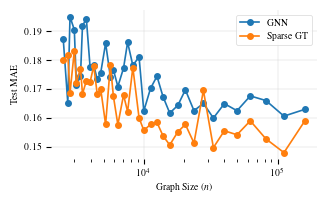

In [ ]:
# =============================================================================
# Figure (b): Transferability Plot - Separate figure for LaTeX subfigure
# =============================================================================
# Re-apply ICML style in case it was reset
setup_icml_style()
plt.rcParams.update({
    "axes.labelsize": 7,  # Controls 'Graph Size (n)' & 'Test MAE'
    "xtick.labelsize": 7,  # Controls the numbers (10^4, 10^5)
    "ytick.labelsize": 7,   # Controls the numbers (0.16, 0.18)
    "legend.fontsize": 7,   # Controls the legend
})

fig_transfer, ax_transfer = plt.subplots(figsize=(ICML_WIDTH_SINGLE, 2.0))

# Label mapping for paper
LABEL_MAP = {'TAGConv': 'GNN', 'SparseGT': 'Sparse GT'}
COLOR_MAP = {'GNN': '#1f77b4', 'Sparse GT': '#ff7f0e'}

# Prepare data
df_plot = best_per_resolution.copy().query('resolution>=5')
df_plot['Model'] = df_plot['layer_type'].map(LABEL_MAP)

# Plot each model
for model_name in ['GNN', 'Sparse GT']:
    model_data = df_plot[df_plot['Model'] == model_name].sort_values('num_nodes')
    ax_transfer.plot(model_data['num_nodes'], model_data[ERROR_COL], 
                     marker='o', label=model_name, color=COLOR_MAP[model_name],
                     linewidth=1.2, markersize=4)

# Log scale for x-axis
ax_transfer.set_xscale('log')

# Axis labels
ax_transfer.set_xlabel(r"Graph Size ($n$)")
ax_transfer.set_ylabel(ERROR_LABEL)

# Grid
ax_transfer.grid(True, color='lightgray', linestyle='-', linewidth=0.3)

# Remove spines for cleaner look
for spine in ax_transfer.spines.values():
    spine.set_visible(False)

# Legend
legend = ax_transfer.legend(loc='upper right', frameon=True, 
                            facecolor='white', framealpha=0.9, edgecolor='lightgray')
legend.get_frame().set_linewidth(0.5)

# Save transferability figure
fig_transfer.savefig('figures/icml_norway_transferability.pdf', bbox_inches='tight', pad_inches=0.02)
fig_transfer.savefig('figures/icml_norway_transferability.png', dpi=300, bbox_inches='tight', pad_inches=0.02)

print("Saved: figures/icml_norway_transferability.pdf")
print("Saved: figures/icml_norway_transferability.png")
plt.show()

## Hybrid Sampling: Norway and Philly side-by-side

Plots transferability across graph resolutions for the **hybrid sampling** experiments.
- Norway: tag `e25TR_norway_hyprid_sampling` (2000x2000 terrain)
- Philly: tag `e28TR_philly_hybrid_sampling_full_test` (1000x1000 terrain)

Generates a single two-column figure with Norway (left) and Philly (right) for the NeurIPS submission.

In [7]:
# =============================================================================
# Load hybrid sampling runs for Norway and Philly
# =============================================================================
import wandb
from tqdm import tqdm

ENTITY = "alelab"
PROJECT = "terrains"

HYBRID_TAGS = {
    "Norway": {"tag": "e25TR_norway_hyprid_sampling", "original_dim": 2000},
    "Philly": {"tag": "e28TR_philly_hybrid_sampling_full_test", "original_dim": 1000},
}

def _extract_resolution(row):
    res_match = re.search(r"res(\d+)", str(row.get("dataset_name", "")))
    if res_match:
        return int(res_match.group(1))
    res_match = re.search(r"res(\d+)", str(row.get("name", "")))
    return int(res_match.group(1)) if res_match else np.nan

def _get_metric_history_mean(entity, project, run_id, metric):
    api = wandb.Api()
    run = api.run(f"{entity}/{project}/{run_id}")
    history = run.history(keys=[metric], pandas=True)
    if history.empty or metric not in history.columns:
        return np.nan
    values = history[metric].dropna()
    return values.mean() if len(values) > 0 else np.nan

def _add_metric_from_history(df, entity, project, source_metric, target_col):
    means = []
    for run_id in tqdm(df["id"], desc=f"Fetching {source_metric}"):
        means.append(_get_metric_history_mean(entity, project, run_id, source_metric))
    df[target_col] = means
    return df

def load_hybrid_runs(tag, original_dim):
    print(f"Fetching runs with tag: {tag}")
    df = wb.load_runs(ENTITY, PROJECT, tags=[tag])
    print(f"  Found {len(df)} runs")

    df["resolution"] = df.apply(_extract_resolution, axis=1)
    df = df.dropna(subset=["resolution"]).copy()
    df["resolution"] = df["resolution"].astype(int)
    df["num_nodes"] = df["resolution"].apply(
        lambda r: ((original_dim - 1) // r + 1) ** 2
    )

    if "layer_type" not in df.columns or df["layer_type"].isna().any():
        df["layer_type"] = df["name"].str.extract(r"(TAGConv|SparseGT)", expand=False)

    # Fetch sparse_gt embedding mode for SparseGT runs to split Random vs Data
    api = wandb.Api()
    embed_modes = {}
    sgt = df[df["layer_type"] == "SparseGT"]
    for _, row in tqdm(sgt.iterrows(), total=len(sgt), desc="  embedding_mode"):
        try:
            run = api.run(f"{ENTITY}/{PROJECT}/{row['id']}")
            embed_modes[row["id"]] = run.config.get("sparse_gt_embedding_mode", None)
        except Exception:
            embed_modes[row["id"]] = None
    df["sparse_gt_embedding_mode"] = df["id"].map(embed_modes)

    def _label(row):
        if row["layer_type"] == "TAGConv":
            return "GNN"
        if row["sparse_gt_embedding_mode"] == "random":
            return "SparseGT-Random"
        if row["sparse_gt_embedding_mode"] == "data":
            return "SparseGT-Data"
        return "SparseGT"
    df["model_label"] = df.apply(_label, axis=1)

    df = _add_metric_from_history(df, ENTITY, PROJECT, "test_batch_mae", "test_mae")
    return df

hybrid_data = {}
for terrain, cfg in HYBRID_TAGS.items():
    hybrid_data[terrain] = load_hybrid_runs(cfg["tag"], cfg["original_dim"])
    print(f"{terrain}: {hybrid_data[terrain]['test_mae'].notna().sum()} valid runs\n")

Fetching runs with tag: e25TR_norway_hyprid_sampling
  Found 37 runs


Fetching test_batch_mae: 100%|██████████| 37/37 [00:36<00:00,  1.00it/s]


Norway: 37 valid runs

Fetching runs with tag: e28TR_philly_hybrid_sampling_full_test
  Found 60 runs


Fetching test_batch_mae: 100%|██████████| 60/60 [00:54<00:00,  1.10it/s]

Philly: 60 valid runs



In [8]:
# Compute best run per (model_label, resolution) for each terrain
hybrid_best = {}
for terrain, df_t in hybrid_data.items():
    df_valid = df_t.dropna(subset=["test_mae"]).query("resolution >= 2")
    best = df_valid.loc[
        df_valid.groupby(["model_label", "resolution"])["test_mae"].idxmin()
    ]
    hybrid_best[terrain] = best
    print(f"{terrain}: {len(best)} best runs across {best['resolution'].nunique()} resolutions")
    print(best.groupby('model_label').size())

Norway: 37 best runs across 19 resolutions
model_label
GNN         19
SparseGT    18
dtype: int64
Philly: 55 best runs across 19 resolutions
model_label
GNN                19
SparseGT-Data      18
SparseGT-Random    18
dtype: int64


Saved: figures/neurips_hybrid_sampling_norway_philly.pdf
Saved: figures/neurips_hybrid_sampling_norway_philly.png


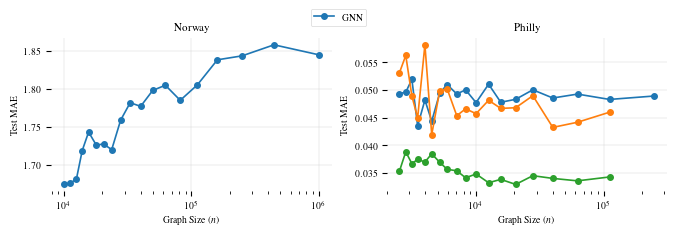

In [9]:
# =============================================================================
# Side-by-side hybrid sampling transferability figure (Norway | Philly)
# =============================================================================
setup_icml_style()
plt.rcParams.update({
    "axes.labelsize": 7,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
    "axes.titlesize": 8,
})

COLOR_MAP_HYBRID = {
    "GNN": "#1f77b4",
    "SparseGT-Random": "#ff7f0e",
    "SparseGT-Data": "#2ca02c",
}
MODEL_ORDER = ["GNN", "SparseGT-Random", "SparseGT-Data"]

fig, axes = plt.subplots(1, 2, figsize=(ICML_WIDTH_DOUBLE, 2.2), sharey=False)

for ax, terrain in zip(axes, ["Norway", "Philly"]):
    best = hybrid_best[terrain]
    for model_name in MODEL_ORDER:
        sub = best[best["model_label"] == model_name].sort_values("num_nodes")
        if sub.empty:
            continue
        ax.plot(
            sub["num_nodes"], sub["test_mae"],
            marker="o", label=model_name,
            color=COLOR_MAP_HYBRID[model_name],
            linewidth=1.2, markersize=4,
        )
    ax.set_xscale("log")
    ax.set_xlabel(r"Graph Size ($n$)")
    ax.set_ylabel("Test MAE")
    ax.set_title(terrain)
    ax.grid(True, color="lightgray", linestyle="-", linewidth=0.3)
    for spine in ax.spines.values():
        spine.set_visible(False)

# Single shared legend
handles, labels = axes[0].get_legend_handles_labels()
legend = fig.legend(
    handles, labels,
    loc="upper center", bbox_to_anchor=(0.5, 1.04),
    ncol=len(labels), frameon=True,
    facecolor="white", framealpha=0.9, edgecolor="lightgray",
)
legend.get_frame().set_linewidth(0.5)

fig.savefig("figures/neurips_hybrid_sampling_norway_philly.pdf",
            bbox_inches="tight", pad_inches=0.02)
fig.savefig("figures/neurips_hybrid_sampling_norway_philly.png",
            dpi=300, bbox_inches="tight", pad_inches=0.02)

print("Saved: figures/neurips_hybrid_sampling_norway_philly.pdf")
print("Saved: figures/neurips_hybrid_sampling_norway_philly.png")
plt.show()